In [40]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import re

# Load dataset
df = pd.read_csv('annotated_republika.csv')
print("Daftar Kolom:", df.columns) # Untuk memastikan kolom 'title' dan 'label' ada
df.head()

Daftar Kolom: Index(['title', 'label', 'label_score'], dtype='object')


,title,label,label_score
0,Krisis Air Bersih di Lebak Meluas Hingga 16 Ke...,non-clickbait,0
1,Disbudpar Kota Malang Panggil Manajemen Museum...,non-clickbait,0
2,Puskeshaji Layani 471.946 Kunjungan Jamaah Haji,non-clickbait,0
3,Bottas tak Menyerah Incar Gelar Juara F1,non-clickbait,0
4,"Capim KPK, Calon Komisioner yang Wajib Teken K...",non-clickbait,0


In [41]:
def find_punc(text):
    return len(re.findall(r'[!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]', str(text)))

def find_uppercase(text):
    return sum(1 for c in str(text) if c.isupper())

def find_lowercase(text):
    return sum(1 for c in str(text) if c.islower())

# Membuat kolom baru di dataframe
df['punc_count'] = df['title'].apply(find_punc)
df['upper_count'] = df['title'].apply(find_uppercase)
df['lower_count'] = df['title'].apply(find_lowercase)

# Membersihkan teks untuk AI
def cleaning(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    return text.lower()

df['cleaned_title'] = df['title'].apply(cleaning)

In [42]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['cleaned_title'])
sequences = tokenizer.texts_to_sequences(df['cleaned_title'])
X_text = pad_sequences(sequences, maxlen=20)

# Mengambil fitur angka
X_punc = df[['punc_count', 'upper_count', 'lower_count']].values

# SOLUSI: Mengubah label teks ke angka 0 dan 1
y = df['label'].map({'non-clickbait': 0, 'clickbait': 1}).values

In [43]:
X_train_title, X_test_title, X_train_punc, X_test_punc, y_train, y_test = train_test_split(
    X_text, X_punc, y, test_size=0.2, random_state=42
)

In [44]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense, concatenate
from tensorflow.keras.models import Model

# Cabang 1: Untuk Judul (LSTM)
lstm_input = Input(shape=(20,))
x1 = Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32)(lstm_input)
x1 = LSTM(32)(x1)
x1 = Dropout(0.5)(x1)

# Cabang 2: Untuk Fitur Angka (MLP)
dense_input = Input(shape=(3,))
x2 = Dense(32, activation='relu')(dense_input)
x2 = Dropout(0.5)(x2)

# Gabungkan
combined = concatenate([x1, x2])
z = Dense(16, activation='relu')(combined)
output = Dense(1, activation='sigmoid')(z)

model = Model(inputs=[lstm_input, dense_input], outputs=output)
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

In [45]:
# 1. Pastikan label menjadi angka (0 dan 1)
y = df['label'].map({'non-clickbait': 0, 'clickbait': 1}).values

# 2. Bagi ulang datanya agar y_train dan y_test ikut terupdate menjadi angka
X_train_title, X_test_title, X_train_punc, X_test_punc, y_train, y_test = train_test_split(
    X_text, X_punc, y, test_size=0.2, random_state=42
)

# 3. Pastikan tipe data y adalah float/int agar tidak ditolak model
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

print("Siap! Data label sudah berubah menjadi angka.")

Siap! Data label sudah berubah menjadi angka.


In [46]:
history = model.fit(
    x=[X_train_title, X_train_punc],
    y=y_train,
    epochs=4,
    batch_size=64,
    validation_data=([X_test_title, X_test_punc], y_test)
)

Epoch 1/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - acc: 0.7558 - loss: 0.6733 - val_acc: 0.8800 - val_loss: 0.4190
Epoch 2/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.7875 - loss: 0.5902 - val_acc: 0.8800 - val_loss: 0.4427
Epoch 3/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8058 - loss: 0.5293 - val_acc: 0.8800 - val_loss: 0.4027
Epoch 4/4
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.8275 - loss: 0.5248 - val_acc: 0.8800 - val_loss: 0.4194


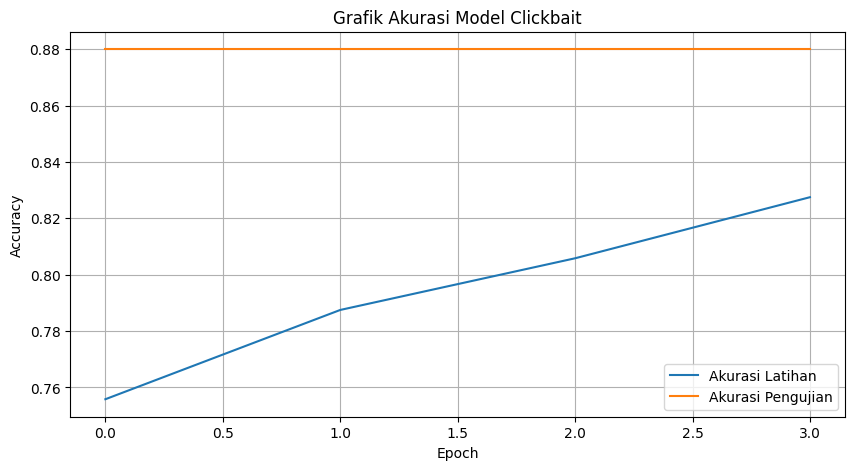

In [47]:
import matplotlib.pyplot as plt

# Membuat grafik akurasi
plt.figure(figsize=(10, 5))
plt.plot(history.history['acc'], label='Akurasi Latihan')
plt.plot(history.history['val_acc'], label='Akurasi Pengujian')
plt.title('Grafik Akurasi Model Clickbait')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()